## Landcover data


In [2]:

import geopandas as gpd
import pandas as pd


#Read in shapefile tags
landcover = gpd.read_file("/fs9/eliviau/hex2vec_project/land_use_framework/data/lc_250_tags") #specify which tags to use


In [3]:
landcover.head(30)

,feature_id,land_cover,geometry
0,0,Bare,"POLYGON ((148.75208 45.55833, 148.75417 45.558..."
1,1,Bare,"POLYGON ((148.78333 45.55625, 148.7875 45.5562..."
2,2,Bare,"POLYGON ((148.78958 45.55625, 148.79167 45.556..."
3,3,Bare,"POLYGON ((148.76042 45.55417, 148.7625 45.5541..."
4,4,Grassland,"POLYGON ((148.7625 45.55417, 148.76667 45.5541..."
5,5,Bare,"POLYGON ((148.76875 45.55417, 148.77083 45.554..."
6,6,Bare,"POLYGON ((148.78125 45.55417, 148.78333 45.554..."
7,7,Grassland,"POLYGON ((148.78333 45.55417, 148.78542 45.554..."
8,8,Grassland,"POLYGON ((148.7875 45.55417, 148.78958 45.5541..."
9,9,Grassland,"POLYGON ((148.79167 45.55417, 148.79583 45.554..."


In [4]:
from srai.regionalizers import geocode_to_region_gdf

# Step 1: Get the boundary for Yamagata prefecture
area = geocode_to_region_gdf("Hokkaido, Japan")
area.crs  # should return EPSG:4326

/home/eliviau/miniconda3/envs/hex2vec_env/lib/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [6]:
area.head()

,geometry
region_id,
"Hokkaido Prefecture, Japan","POLYGON ((139.06728 41.51453, 139.06751 41.506..."


In [7]:
from srai.regionalizers import H3Regionalizer

# Step 2: Create H3 hexagons for Hokkaido
regionalizer = H3Regionalizer(resolution=7)  # resolution 9 = ~500m hexes
regions = regionalizer.transform(area)

regions.head()

,geometry
region_id,
872ea9cd4ffffff,"POLYGON ((143.36724 44.38845, 143.36326 44.400..."
872eadce2ffffff,"POLYGON ((144.32251 43.55958, 144.31872 43.572..."
872e1bc23ffffff,"POLYGON ((141.71423 42.84763, 141.71011 42.859..."
872e1aa94ffffff,"POLYGON ((142.33694 43.05029, 142.33289 43.062..."
872e18d2cffffff,"POLYGON ((142.77708 41.95575, 142.77316 41.968..."


In [8]:
regions.shape

(28902, 1)

step 3 : join 

In [9]:
from srai.joiners import IntersectionJoiner

# Make sure CRS matches!
landcover = landcover.to_crs(regions.crs)

# Step 3: Use IntersectionJoiner to match land cover to hexagons
joiner = IntersectionJoiner()
joined = joiner.transform(regions, landcover)

# Preview the result
joined.head()


Empty DataFrame
Columns: []
Index: [(872e8db63ffffff, 125), (872e8db63ffffff, 166), (872e8db60ffffff, 167), (872e8db63ffffff, 167), (872e8db63ffffff, 169)]

In [10]:
joined.shape

(460367, 0)

In [11]:
# Bring region_id back as a column
joined = joined.reset_index()

# Now merge safely
joined_with_tags = joined.merge(
    landcover[["feature_id", "land_cover"]],
    on="feature_id",
    how="left"
)

In [12]:
joined_with_tags.head()

,region_id,feature_id,land_cover
0,872e8db63ffffff,125,Bare
1,872e8db63ffffff,166,Bare
2,872e8db60ffffff,167,Bare
3,872e8db63ffffff,167,Bare
4,872e8db63ffffff,169,Wetland


In [13]:
ahp_landcover_scores = {
    "Cropland": 2,  # tbc with experts - political compromise
    "Grassland": 7,
    "Bare":10,
    "DBF": 0,
    "DNF": 0,
    "EBF": 0,
    "ENF": 0,
    "Wetland": 0,  #
    "Water": 0, #SEE SOLAR PP on waterlands - but not river
    "Built-up": 6, #tricky variable --> rooftops vs prximity to villages...
    "Solar Panel": None,
    "Paddy Field": 0,
    "Greenhouse": 0,
    "Bamboo Forest": 0,
    "NULL": None
}


In [14]:
joined_with_tags["landcover_score"] = joined_with_tags["land_cover"].map(ahp_landcover_scores)


In [15]:
hex_scores = joined_with_tags.groupby("region_id")["landcover_score"].mean().reset_index()
hex_scores.columns = ["region_id", "landcover_score"]


In [16]:
# Merge scores into hexagon GeoDataFrame
regions_scored = regions.merge(hex_scores, on="region_id", how="left")


In [17]:
regions_scored.head(30)

,region_id,geometry,landcover_score
0,872ea9cd4ffffff,"POLYGON ((143.36724 44.38845, 143.36326 44.400...",0.000000
1,872eadce2ffffff,"POLYGON ((144.32251 43.55958, 144.31872 43.572...",1.390244
2,872e1bc23ffffff,"POLYGON ((141.71423 42.84763, 141.71011 42.859...",3.133333
3,872e1aa94ffffff,"POLYGON ((142.33694 43.05029, 142.33289 43.062...",2.800000
4,872e18d2cffffff,"POLYGON ((142.77708 41.95575, 142.77316 41.968...",NaN
5,872e13459ffffff,"POLYGON ((144.91594 43.08301, 144.91227 43.095...",0.000000
6,872ea9760ffffff,"POLYGON ((142.65704 44.42937, 142.65296 44.441...",5.727273
7,872ead8f4ffffff,"POLYGON ((144.06321 43.22738, 144.05941 43.239...",0.000000
8,872e1ad29ffffff,"POLYGON ((143.11373 43.02459, 143.1098 43.0369...",3.050000
9,872e1b731ffffff,"POLYGON ((141.1436 43.14867, 141.13939 43.1608...",2.103448


In [18]:
#regions_scored save to output
regions_scored.to_file("/fs9/eliviau/hex2vec_project/Eli_test/ELIS_PROJECT/MCDM_project/outputs and maps/hokkaido_ahp_landcoverreso7forenv.geojson", driver="GeoJSON")

In [23]:
from srai.plotting import plot_numeric_data

#remettre le index 
regions_scored = regions_scored.set_index("region_id")

m = plot_numeric_data(regions_scored, "landcover_score", colormap="YlGnBu", opacity=0.6)
m.save("landcover_hokkaido_map.html")


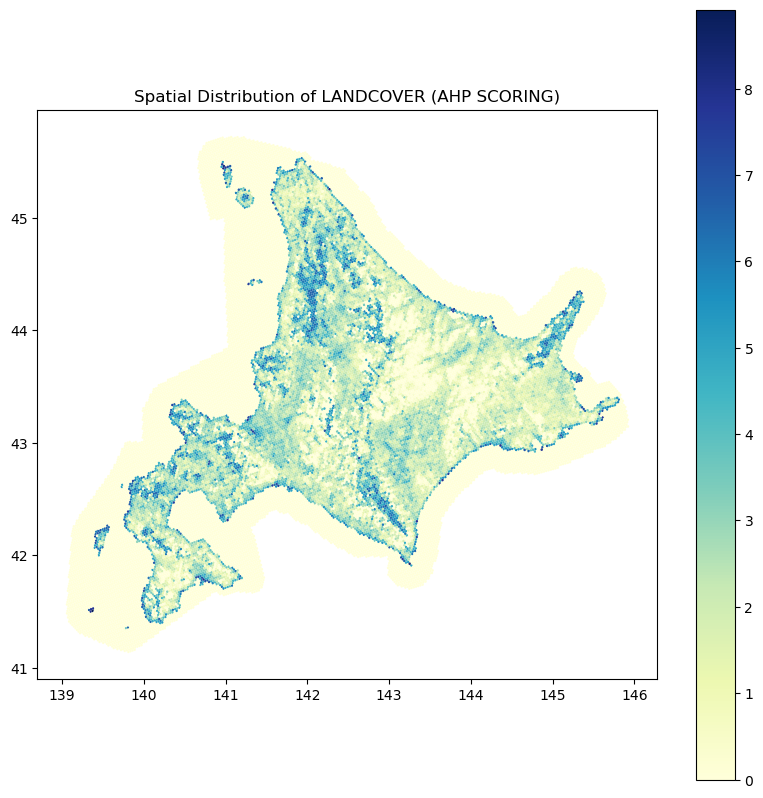

In [19]:
#other map 

#other quickmap 
# If you still have 'regions' geodataframe loaded:


from matplotlib import pyplot as plt


regions_scored.plot(
    column='landcover_score',
    cmap='YlGnBu',
    legend=True,
    figsize=(10,10)
)
plt.title("Spatial Distribution of LANDCOVER (AHP SCORING)")
plt.show()


/tmp/ipykernel_31187/2016388870.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


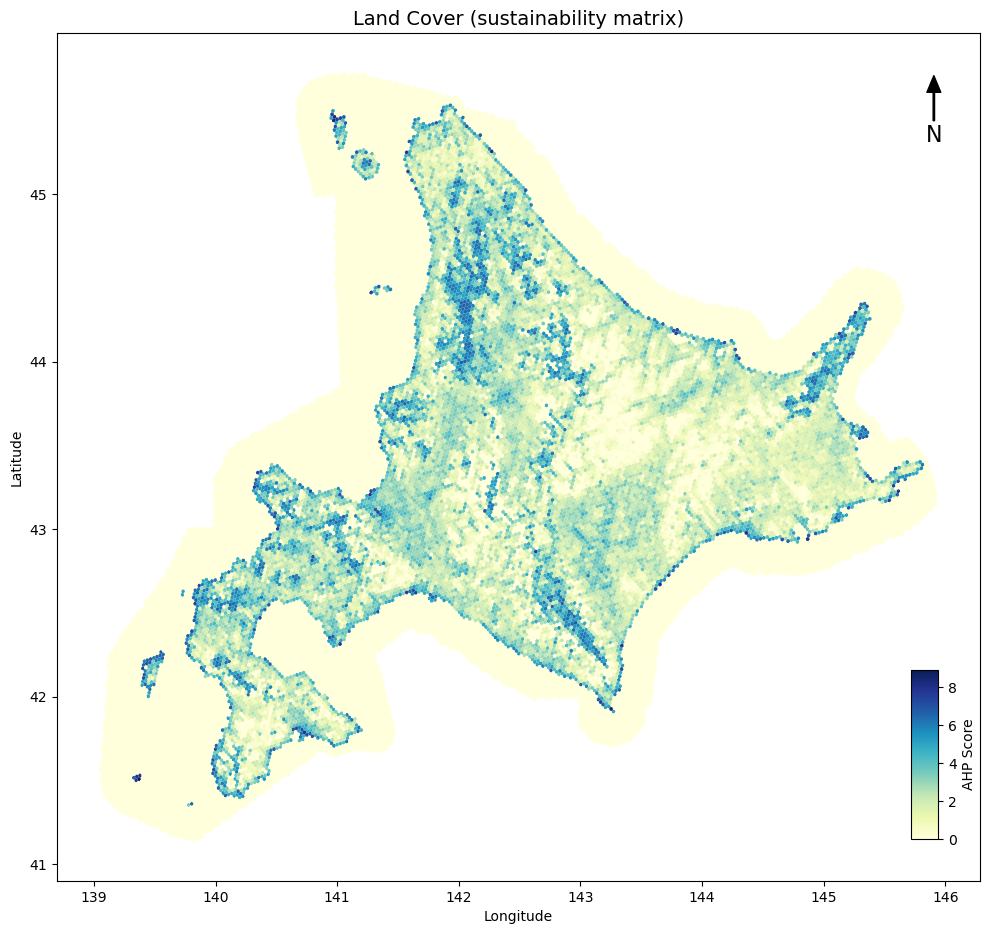

In [21]:
import geopandas as gpd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


# 1. Create plot
fig, ax = plt.subplots(figsize=(10, 10))

# 2. Plot main map
main_plot = regions_scored.plot(
    column='landcover_score',
    cmap='YlGnBu',
    legend=False,  # We'll add a custom one
    ax=ax,
    edgecolor='none'
)

# 3. Add colorbar INSIDE the plot area
sm = plt.cm.ScalarMappable(cmap='YlGnBu', norm=plt.Normalize(vmin=regions_scored['landcover_score'].min(), vmax=regions_scored['landcover_score'].max()))
sm._A = []

cax = inset_axes(ax, width="3%", height="20%", loc='lower right', borderpad=3)  # Adjust size/position here
cbar = fig.colorbar(sm, cax=cax, orientation='vertical')
cbar.set_label("AHP Score")

# 4. Coordinate grid and title
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Land Cover (sustainability matrix)", fontsize=14)

# Add north arrow but arrow shorter
ax.annotate('N',
            xy=(0.95, 0.95), xytext=(0.95, 0.88),
            xycoords='axes fraction',
            ha='center', va='center',
            fontsize=16,
            arrowprops=dict(facecolor='black', width=1, headwidth=10)) 

plt.tight_layout()
plt.show()
